In [1]:
%pip install scikit-learn shap dice-ml pandas numpy matplotlib

/Users/viegas/Projects/ufv/mestrado/causality-for-data-scientists-course/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Descomente isso se tiver no Google Colab!!
# !git clone https://github.com/gfviegas/causality-for-data-scientists-course.git
# %cd causality-for-data-scientists-course/notebooks/extras

# Explicabilidade Contrafactual vs. Explicabilidade por Atribuição

> **Notebook extra.** Esse material não entra na demonstração ao vivo do curso (o tempo não fecha pra mais um notebook), mas fica aqui pra quem quiser se aprofundar depois.

No Notebook 4 você viu causalidade sendo usada pra escolher e construir atributos melhores. Esse notebook extra é sobre outra aplicação de ML: **explicar uma previsão individual**.

Métodos de atribuição, como o **SHAP**, respondem *"quais atributos pesaram mais nessa previsão?"*. Métodos contrafactuais, como o **DiCE**, respondem uma pergunta diferente: *"o que precisaria ser diferente nesse caso pra o resultado mudar?"*. A pergunta contrafactual está literalmente no terceiro degrau da Hierarquia Causal de Pearl (você viu isso lá no começo do curso) — imaginar um mundo em que a entrada tivesse sido diferente é, por definição, uma pergunta causal. Quando existe um grafo causal disponível, a geração de contrafactuais pode ser restringida por ele, garantindo que as mudanças propostas sejam coerentes (e não só "aumenta a renda" enquanto tudo que depende da renda continua parado).

## Parte 1 — Treinando um classificador no German Credit

Vamos usar o clássico dataset **German Credit** (UCI / OpenML `credit-g`): cerca de 1000 pedidos de empréstimo, rotulados como `good` (pago) ou `bad` (calote/risco de rejeição). Ele mistura atributos numéricos (duração, valor do crédito, idade, ...) e categóricos (situação da conta corrente, histórico de crédito, propósito do empréstimo, ...).

Construímos um único `Pipeline` do `sklearn` — um `ColumnTransformer` (one-hot encoding pras categóricas, passagem direta pras numéricas) alimentando um `GradientBoostingClassifier` — pra poder passar o mesmo objeto tanto pro SHAP quanto pro DiCE mais adiante.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from sklearn.datasets import fetch_openml

np.random.seed(42)

credit = fetch_openml('credit-g', version=1, as_frame=True)
df = credit.frame.copy()

print(df.shape)
print(df.dtypes.value_counts())
df.head()

(1000, 21)
int64       7
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
Name: count, dtype: int64


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [4]:
target_col = 'class'
df[target_col] = df[target_col].astype(str)
print(df[target_col].value_counts())

# 1 = bad (mais risco / efetivamente "rejeitado"), 0 = good
y = (df[target_col] == 'bad').astype(int)
X = df.drop(columns=[target_col])

categorical_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('categóricas:', categorical_cols)
print('numéricas:', numeric_cols)

class
good    700
bad     300
Name: count, dtype: int64
categóricas: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
numéricas: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numeric_cols),
])

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('classifier', GradientBoostingClassifier(random_state=42)),
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Acurácia no teste: {acc:.3f}')
print(classification_report(y_test, y_pred, target_names=['good (0)', 'bad (1)']))

Acurácia no teste: 0.760
              precision    recall  f1-score   support

    good (0)       0.80      0.87      0.84       175
     bad (1)       0.63      0.49      0.55        75

    accuracy                           0.76       250
   macro avg       0.71      0.68      0.69       250
weighted avg       0.75      0.76      0.75       250



In [6]:
# Escolhe um solicitante previsto como alto risco ("rejeitado") pra explicar no resto do notebook
test_preds = pipeline.predict(X_test)
rejected_idx = X_test.index[test_preds == 1]

# Prefere um caso que era 'good' de verdade mas foi previsto como 'bad' (um caso de fronteira, mais interessante)
misclassified = X_test.index[(test_preds == 1) & (y_test.loc[X_test.index] == 0)]
applicant_idx = misclassified[0] if len(misclassified) > 0 else rejected_idx[0]

applicant = X_test.loc[[applicant_idx]]
print('Índice do solicitante escolhido:', applicant_idx)
print('Rótulo verdadeiro:', 'bad' if y_test.loc[applicant_idx] == 1 else 'good')
print('Rótulo previsto:', 'bad' if pipeline.predict(applicant)[0] == 1 else 'good')
applicant.T

Índice do solicitante escolhido: 477
Rótulo verdadeiro: good
Rótulo previsto: bad


,477
checking_status,>=200
duration,24
credit_history,existing paid
purpose,radio/tv
credit_amount,5152
savings_status,<100
employment,4<=X<7
installment_commitment,4
personal_status,male single
other_parties,none


## Parte 2 — Atribuição: SHAP

O SHAP atribui a cada atributo uma contribuição (com sinal) pra saída do modelo, numa previsão específica. Explicamos o estágio `GradientBoostingClassifier` direto sobre a matriz **já transformada em one-hot** — isso é bem mais rápido e mais exato do que embrulhar o pipeline inteiro num explicador genérico (agnóstico de modelo), e deixa a gente ver exatamente qual categoria do one-hot pesou.

In [7]:
import pandas as pd
import shap

X_train_enc = preprocess.transform(X_train)
X_test_enc = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()

X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values = explainer(X_test_enc_df)

applicant_pos = X_test.index.get_loc(applicant_idx)
applicant_shap = shap_values[applicant_pos]
print('Valor base (saída esperada do modelo):', applicant_shap.base_values)
print('Saída do modelo pra esse solicitante:', applicant_shap.base_values + applicant_shap.values.sum())

Valor base (saída esperada do modelo): -1.217202332780559
Saída do modelo pra esse solicitante: 0.12761006933082575


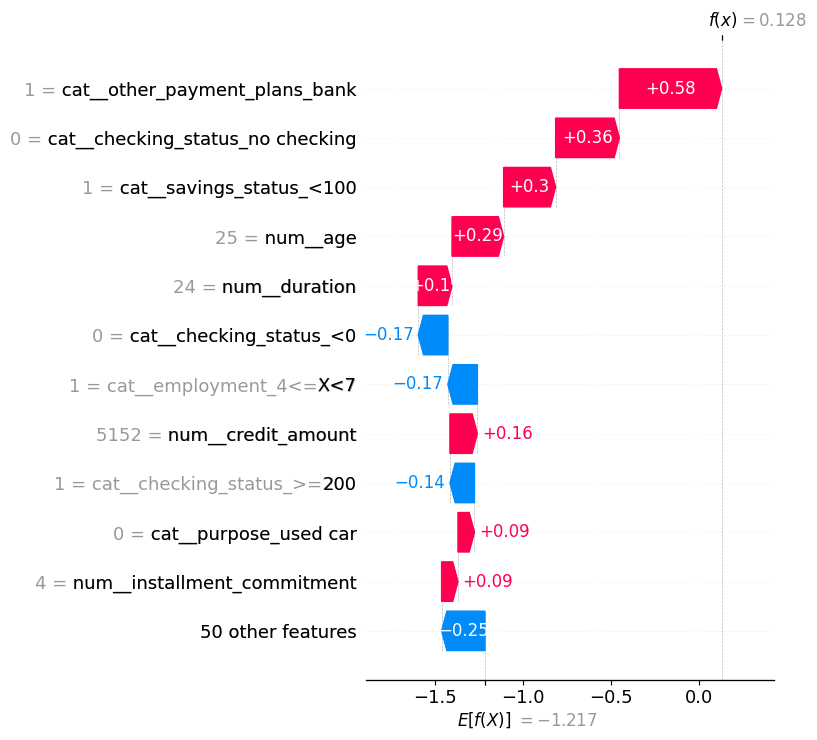

In [8]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(applicant_shap, max_display=12, show=False)
plt.tight_layout()
plt.savefig('../../figures/7_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
shap_series = pd.Series(applicant_shap.values, index=feature_names).sort_values(key=np.abs, ascending=False)
top3 = shap_series.head(3)
print('Top 3 atributos do SHAP pra esse solicitante (positivo = empurra pra "bad"):')
print(top3)

Top 3 atributos do SHAP pra esse solicitante (positivo = empurra pra "bad"):
cat__other_payment_plans_bank       0.581310
cat__checking_status_no checking    0.362267
cat__savings_status_<100            0.295545
dtype: float64


Os atributos com maior peso no SHAP pra esse solicitante misturam variáveis financeiras (ex.: `checking_status`, `duration`, `credit_amount`) e — com frequência — proxies categóricos como `foreign_worker`, `personal_status` ou `purpose`. O SHAP não consegue nos dizer se um atributo tipo `foreign_worker` importa porque é *causalmente* relevante pro risco de inadimplência, ou porque simplesmente se correlaciona com causas verdadeiras (estabilidade no emprego, renda) que acabaram dentro do mesmo modelo. Essa é exatamente a ambiguidade que o capítulo do curso menciona: **atribuição responde "o que pesou nessa previsão", não "o que causou esse resultado".**

## Parte 3 — Explicações Contrafactuais: DiCE

O DiCE busca **instâncias contrafactuais diversas**: versões minimamente alteradas do perfil do solicitante que fazem o modelo mudar a previsão pra "good". Diferente do SHAP, o DiCE consegue embrulhar o `Pipeline` inteiro do `sklearn` direto (ele só precisa de `predict`/`predict_proba`), então não precisa de nenhuma codificação manual.

In [10]:
import dice_ml

dice_df = pd.concat([X, y.rename(target_col)], axis=1)

d = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=numeric_cols,
    outcome_name=target_col,
)
m = dice_ml.Model(model=pipeline, backend='sklearn')
exp = dice_ml.Dice(d, m, method='random')

query_instance = X.loc[[applicant_idx]]
cf_result = exp.generate_counterfactuals(
    query_instance, total_CFs=3, desired_class='opposite', random_seed=42
)
cf_result.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11.89it/s]

Query instance (original outcome : 1)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,>=200,24,existing paid,radio/tv,5152,<100,4<=X<7,4,male single,none,...,car,25,bank,own,1,skilled,1,none,yes,1



Diverse Counterfactual set (new outcome: 0)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,-,-,-,-,-,-,-,-,-,guarantor,...,-,-,-,for free,-,-,-,-,-,0
1,-,-,-,-,-,-,-,-,-,-,...,-,65,-,-,-,-,-,-,-,0
2,-,14,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0


In [11]:
cf_df = cf_result.cf_examples_list[0].final_cfs_df
orig = query_instance.iloc[0]

print('Contrafactuais sem restrição — mudanças necessárias pra virar a previsão pra "good":\n')
for i, row in cf_df.iterrows():
    changes = []
    for col in X.columns:
        if str(row[col]) != str(orig[col]):
            changes.append(f'{col}: {orig[col]} -> {row[col]}')
    print(f'Contrafactual {i}:')
    for c in changes:
        print('  -', c)
    print()

Contrafactuais sem restrição — mudanças necessárias pra virar a previsão pra "good":

Contrafactual 0:
  - other_parties: none -> guarantor
  - housing: own -> for free

Contrafactual 1:
  - age: 25 -> 65

Contrafactual 2:
  - duration: 24 -> 14



Compare o número de atributos que o DiCE realmente mudou pra chegar num resultado diferente com a lista dos top-3 do SHAP ali em cima. O DiCE está otimizando diretamente pra um conjunto *pequeno e eficaz* de mudanças — ele responde "o que eu deveria mudar?", não uma classificação de tudo por contribuição.

## Parte 4 — Tornando os Contrafactuais Causalmente Plausíveis

Os contrafactuais sem restrição de cima podem sugerir mudanças que não são realisticamente acionáveis — por exemplo, o DiCE é livre pra alterar `age`, `foreign_worker` ou `personal_status`, e nenhum desses um solicitante pode simplesmente escolher mudar. Um gerador ciente de causalidade deveria variar só atributos plausivelmente mutáveis, e manter valores numéricos dentro de uma faixa realista.

Não estamos construindo um modelo causal estrutural completo aqui (isso exigiria uma SCM feita à mão pra esse dataset), mas dá pra aplicar as restrições práticas que o DiCE já expõe: `features_to_vary` e `permitted_range`.

In [12]:
immutable = ['age', 'foreign_worker', 'personal_status']
mutable_features = [c for c in X.columns if c not in immutable]

changed_in_unconstrained = set()
for i, row in cf_df.iterrows():
    for col in X.columns:
        if str(row[col]) != str(orig[col]):
            changed_in_unconstrained.add(col)

flagged = changed_in_unconstrained & set(immutable)
print('Atributos imutáveis que a rodada sem restrição propôs mudar:', flagged if flagged else 'nenhum nessa rodada — mas eles continuam elegíveis pra mudar, o que já é o problema: nada impede o DiCE de mexer neles.')

Atributos imutáveis que a rodada sem restrição propôs mudar: {'age'}


In [13]:
permitted_range = {
    'duration': [orig['duration'], min(df['duration'].max(), orig['duration'] + 24)],
    'credit_amount': [max(df['credit_amount'].min(), orig['credit_amount'] - 2000), orig['credit_amount']],
}
permitted_range = {k: [float(v[0]), float(v[1])] for k, v in permitted_range.items() if k in numeric_cols}

cf_result_constrained = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class='opposite',
    features_to_vary=mutable_features,
    permitted_range=permitted_range,
    random_seed=42,
)
cf_result_constrained.visualize_as_dataframe(show_only_changes=True)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 12.63it/s]

Query instance (original outcome : 1)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,>=200,24,existing paid,radio/tv,5152,<100,4<=X<7,4,male single,none,...,car,25,bank,own,1,skilled,1,none,yes,1



Diverse Counterfactual set (new outcome: 0)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,-,-,-,-,-,-,1<=X<4,1,-,-,...,-,-,-,-,-,-,-,-,-,0
1,-,-,all paid,-,-,-,-,-,-,-,...,-,-,stores,-,-,-,-,-,-,0
2,-,-,delayed previously,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0


In [14]:
cf_df_constrained = cf_result_constrained.cf_examples_list[0].final_cfs_df
print('Contrafactuais com restrição — só atributos mutáveis e com faixa plausível podem mudar:\n')
for i, row in cf_df_constrained.iterrows():
    changes = []
    for col in X.columns:
        if str(row[col]) != str(orig[col]):
            changes.append(f'{col}: {orig[col]} -> {row[col]}')
    print(f'Contrafactual {i}:')
    for c in changes:
        print('  -', c)
    print()

Contrafactuais com restrição — só atributos mutáveis e com faixa plausível podem mudar:

Contrafactual 0:
  - employment: 4<=X<7 -> 1<=X<4
  - installment_commitment: 4 -> 1

Contrafactual 1:
  - credit_history: existing paid -> all paid
  - other_payment_plans: bank -> stores

Contrafactual 2:
  - credit_history: existing paid -> delayed previously
  - residence_since: 2 -> 1



**Nota sobre o escopo:** isso é uma demo de *restrição de plausibilidade* (`features_to_vary` + `permitted_range`), não um DiCE restringido por grafo causal completo. Um gerador causalmente fundamentado propagaria uma mudança proposta através de um modelo causal estrutural (ex.: aumentar o tempo de emprego também deveria mudar a elegibilidade de `credit_amount`) — o DiCE tem um argumento `causal_graph` pra isso, mas exige uma SCM feita à mão pro dataset, o que foge do escopo aqui. A rodada com restrição já remove as sugestões mais obviamente não-acionáveis e mantém as mudanças numéricas dentro de uma faixa realista.

## Parte 5 — Quando SHAP e DiCE Concordam, e Quando Não

Agora contrastamos duas situações:

1. Um caso em que o principal atributo do SHAP e a mudança sugerida pelo DiCE **apontam pro mesmo atributo acionável** — os dois métodos concordam sobre o que importa e o que poderia ser mudado.
2. Um caso em que o SHAP aponta um atributo como principal, mas o DiCE (com restrição) **se recusa a tocar nele** porque foi marcado como não-acionável — um lembrete de que "importante" e "acionável" não são a mesma coisa.

In [15]:
shap_top_feature_raw = None
for feat in shap_series.index:
    # mapeia o nome codificado (one-hot / passthrough) de volta pra coluna original
    raw_candidates = [c for c in X.columns if feat.startswith(f'num__{c}') or feat.startswith(f'cat__{c}_')]
    if raw_candidates:
        shap_top_feature_raw = raw_candidates[0]
        break

dice_changed_features = set()
for i, row in cf_df_constrained.iterrows():
    for col in X.columns:
        if str(row[col]) != str(orig[col]):
            dice_changed_features.add(col)

print('Atributo original com maior peso no SHAP:', shap_top_feature_raw)
print('Atributos alterados pelo DiCE (com restrição):', dice_changed_features)
print('Concordância:', shap_top_feature_raw in dice_changed_features)

Atributo original com maior peso no SHAP: other_payment_plans
Atributos alterados pelo DiCE (com restrição): {'other_payment_plans', 'installment_commitment', 'residence_since', 'credit_history', 'employment'}
Concordância: True


In [16]:
shap_top3_raw = []
for feat in shap_series.index:
    raw_candidates = [c for c in X.columns if feat.startswith(f'num__{c}') or feat.startswith(f'cat__{c}_')]
    if raw_candidates and raw_candidates[0] not in shap_top3_raw:
        shap_top3_raw.append(raw_candidates[0])
    if len(shap_top3_raw) == 3:
        break

immutable_in_shap_top3 = [f for f in shap_top3_raw if f in immutable]
print('Top-3 atributos originais do SHAP:', shap_top3_raw)
print('Desses, marcados como não-acionáveis (excluídos da busca do DiCE):', immutable_in_shap_top3)

Top-3 atributos originais do SHAP: ['other_payment_plans', 'checking_status', 'savings_status']
Desses, marcados como não-acionáveis (excluídos da busca do DiCE): []


Se algum dos principais atributos do SHAP for um atributo imutável (idade, nacionalidade, estado civil), é exatamente a divergência que o capítulo do curso destaca: **o SHAP vai tranquilamente reportar que um atributo demográfico imutável "pesou" na decisão, enquanto o DiCE — por construção — nunca vai sugerir mudá-lo**, porque recomendar mudar sua idade ou nacionalidade não é um recurso acionável. Esse é o ganho prático de perguntar "o que eu deveria mudar?" em vez de só "o que pesou?".

## Concluindo...

### 1. Atribuição e contrafactuais respondem perguntas diferentes

O SHAP responde *"o que pesou nessa previsão?"* — um ranking sobre todos os atributos, incluindo os que ninguém consegue agir sobre. O DiCE responde *"o que eu deveria mudar?"* — um conjunto pequeno e acionável de edições que vira o resultado.

### 2. Atribuição é ambígua sob correlação

Um valor alto de SHAP num atributo proxy (ex.: `foreign_worker`, `personal_status`) pode refletir um efeito causal de verdade, ou só refletir correlação com uma causa verdadeira que ficou de fora do modelo. A geração de contrafactuais contorna isso otimizando direto pra mudança acionável, não pra explicar variância.

### 3. Contrafactuais sem restrição podem ser implausíveis

Sem restrição, o DiCE é livre pra propor mudanças em atributos imutáveis. Adicionar restrições de `features_to_vary` e `permitted_range` — idealmente derivadas de um entendimento causal de quais variáveis são mutáveis e como se relacionam — torna as sugestões de recurso realistas, em vez de só matematicamente válidas.

### 4. Contrafactuais restringidos por grafo causal completo vão além

Com um modelo causal estrutural, um gerador de contrafactuais consegue propagar uma mudança proposta pelos seus efeitos posteriores (ex.: renda subir quando o tempo de emprego sobe), garantindo consistência interna. Esse notebook aplicou restrições de plausibilidade mais simples; sistemas de produção que lidam com recurso (crédito, contratação, admissão) deveriam mirar na versão causalmente fundamentada.